---

# LESSON 30: HISTOGRAMS

---

>---
>**Histograms** are used to visualize the distribution of a numeric variable
>
>- `ax.hist(` `series`, `density=`, `alpha=`, `bins=` `)`
>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)
df.head(3)

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583
1,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000
2,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000


In [3]:
df = df.groupby('region_name').agg({'median_active_list_price':'mean'}).round()
df

,median_active_list_price
region_name,
"Abbeville County, SC",202811.0
"Acadia Parish, LA",142611.0
"Ada County, ID",427643.0
"Adair County, IA",116280.0
"Adair County, MO",141012.0
...,...
"York County, VA",331959.0
"Young County, TX",165593.0
"Yuba County, CA",352322.0


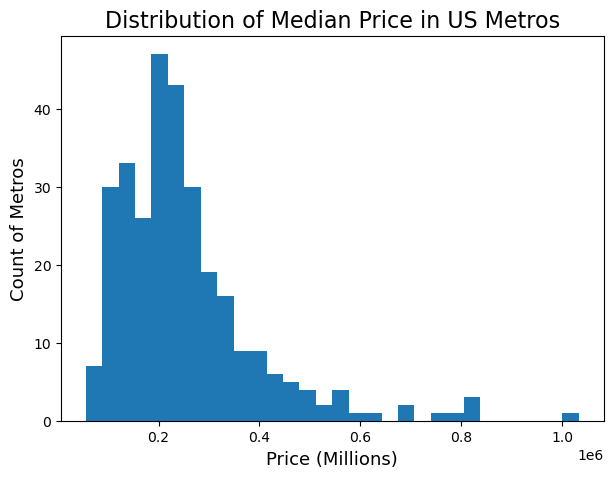

In [4]:
fig, ax = plt.subplots(figsize=(7,5))

ax.hist(df.iloc[:300], bins=30)

ax.set_title('Distribution of Median Price in US Metros', fontsize=16)
ax.set_xlabel('Price (Millions)', fontsize=13)
ax.set_ylabel('Count of Metros', fontsize=13)

plt.show()

<br><br>

---

## LABORATORY No.1

In [5]:
df1 = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin', 'period_end'])
df1.head(3)

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985
1,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214
2,Los Angeles,2019-01-21,2019-04-14,13372.0,18580.0,20097.0,58.2,697324.3,18.764906


In [6]:
df1 = (df1
    .pivot_table(index='period_end', columns='region_name', 
                 values='median_active_list_price', aggfunc='sum')
    .resample('W').sum().round())

df1 = df1.assign(
    Los_Angeles_growth = (df1['Los Angeles'].diff()/df1['Los Angeles'].shift())*100,
    San_Diego_growth = (df1['San Diego'].diff() / df1['San Diego'].shift())*100,
    San_Francisco_growth = (df1['San Francisco'].diff() / df1['San Francisco'].shift())*100
)
df1.head()

region_name,Los Angeles,San Diego,San Francisco,Los_Angeles_growth,San_Diego_growth,San_Francisco_growth
period_end,,,,,,
2017-03-26,611561.0,618571.0,1229019.0,NaN,NaN,NaN
2017-04-02,614061.0,621738.0,1233394.0,0.408790,0.511986,0.355975
2017-04-09,617311.0,625821.0,1239977.0,0.529263,0.656707,0.533731
2017-04-16,620644.0,629492.0,1247977.0,0.539922,0.586589,0.645173
2017-04-23,624542.0,632824.0,1253310.0,0.628057,0.529316,0.427332


In [7]:
df1 = df1.iloc[1:]
df1.head(3)

region_name,Los Angeles,San Diego,San Francisco,Los_Angeles_growth,San_Diego_growth,San_Francisco_growth
period_end,,,,,,
2017-04-02,614061.0,621738.0,1233394.0,0.408790,0.511986,0.355975
2017-04-09,617311.0,625821.0,1239977.0,0.529263,0.656707,0.533731
2017-04-16,620644.0,629492.0,1247977.0,0.539922,0.586589,0.645173


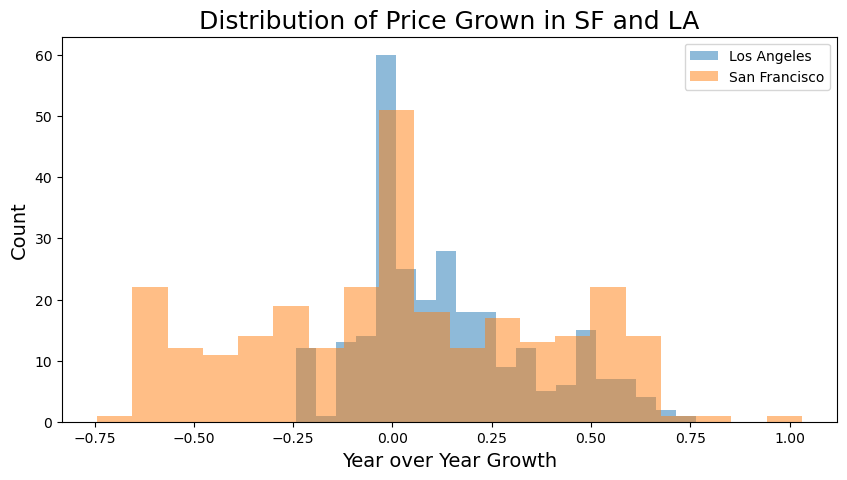

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df1.Los_Angeles_growth, alpha=0.5, bins=20, label='Los Angeles')
# ax.hist(df1.San_Diego_growth, alpha=0.5, bins=20, label='San Diego')
ax.hist(df1.San_Francisco_growth, alpha=0.5, bins=20, label='San Francisco')

ax.set_title('Distribution of Price Grown in SF and LA', fontsize=18)
ax.set_xlabel('Year over Year Growth', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

ax.legend()
plt.show()

<br><br>

---

## LABORATORY No.2

In [9]:
df2 = pd.read_csv('../Data/Diamonds Prices2022.csv', 
                 usecols=[ 'carat', 'cut', 'color', 'clarity', 'depth',
                           'table', 'price', 'x', 'y', 'z'])
df2.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


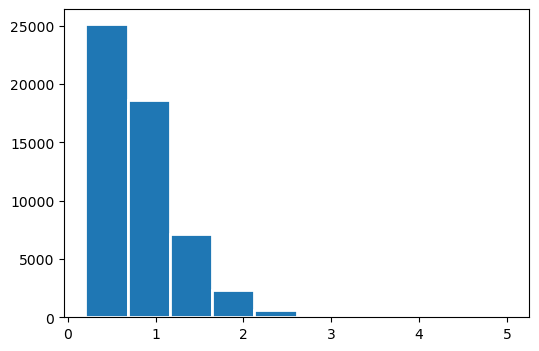

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df2.carat, bins=10,
        edgecolor='white', linewidth=2)

plt.show()

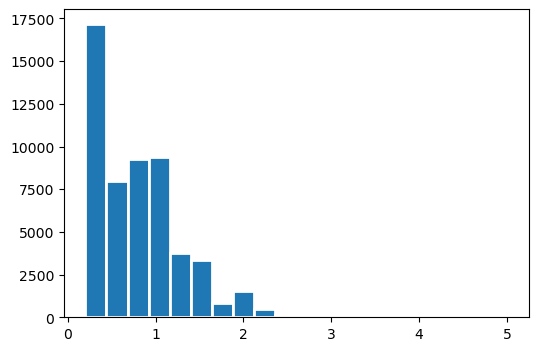

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df2.carat, bins=20,
        edgecolor='white', linewidth=2)

plt.show()

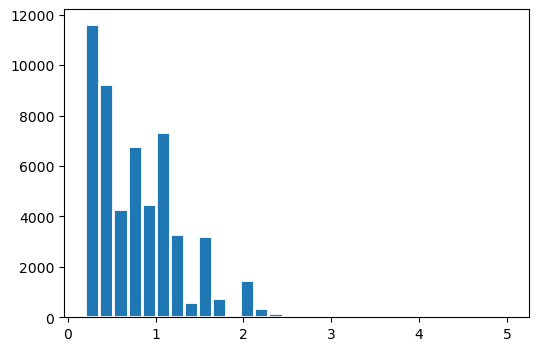

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df2.carat, bins=30,
        edgecolor='white', linewidth=2)

plt.show()

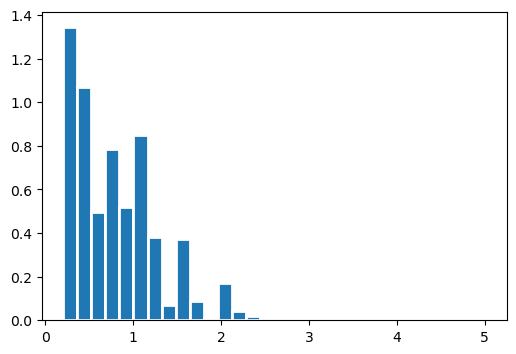

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df2.carat, bins=30, density=True,
        edgecolor='white', linewidth=2)

plt.show()

<br><br>

---

## LABORATORY No.3

In [14]:
df2.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


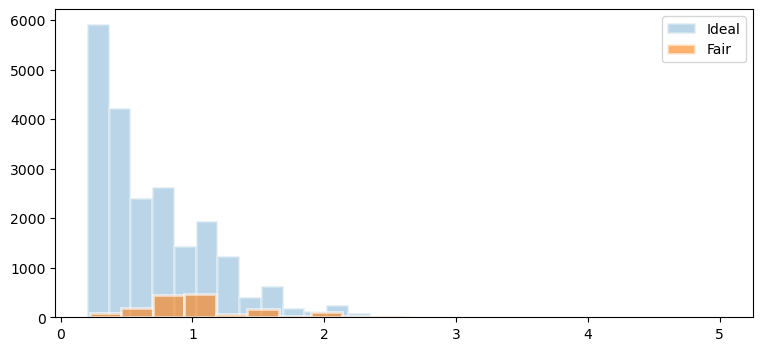

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df2.query("cut == 'Ideal'").carat, 
        bins=20, density=False, label='Ideal',
        edgecolor='white', linewidth=2, alpha=0.3)

ax.hist(df2.query("cut == 'Fair'").carat,
        bins=20, density=False, label='Fair',
        edgecolor='white', linewidth=2, alpha=0.6)

ax.legend()
plt.show()

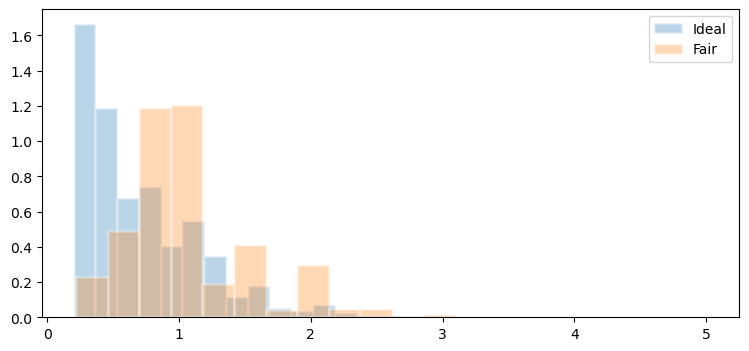

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df2.query("cut == 'Ideal'").carat, 
        bins=20, density=True, label='Ideal',
        edgecolor='white', linewidth=2, alpha=0.3)

ax.hist(df2.query("cut == 'Fair'").carat,
        bins=20, density=True, label='Fair',
        edgecolor='white', linewidth=2, alpha=0.3)

ax.legend()
plt.show()